In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
class SalesDataAnalyzer:
    
    def __init__(self):
        self.df = None
        self.current_figure = None
        print("Sales Data Analyzer Initialized Successfully.")
        
    def load_data(self):

        print("\n== Load Dataset ==")

        path = input("Enter CSV file path: ")

        try:
           self.df = pd.read_csv(path)

           self.df["Date"] = pd.to_datetime(self.df["Date"], format="%Y-%m-%d")

           print("\nDataset loaded successfully!")
           print(f"Rows: {self.df.shape[0]}")
           print(f"Columns: {self.df.shape[1]}")

        except FileNotFoundError:
            print("Error: File not found.")

        except pd.errors.EmptyDataError:
            print("Error: File is empty.")

        except pd.errors.ParserError:
            print("Error: Invalid CSV file.")

        except PermissionError:
            print("Error: Permission denied.")

        except Exception as e:
            print("Unexpected Error:", e)

    def explore_data(self):

        if self.df is None:
            print("Please load dataset first.")
            return

        print("\n========== Explore Data ==========")
        print("1. Display First 5 Rows")
        print("2. Display Last 5 Rows")
        print("3. Display Column Names")
        print("4. Display Data Types")
        print("5. Display Basic Information")
        print("==================================")

        choice = input("Enter your choice: ")

        match choice:

            case "1":
                print(self.df.head())

            case "2":
                print(self.df.tail())

            case "3":
                print(self.df.columns)

            case "4":
                print(self.df.dtypes)

            case "5":
               self.df.info()

            case _:
                print("Invalid Choice.")
                    
    def dataframe_operations(self):

        if self.df is None:
            print("\nPlease load the dataset first.")
            return

        print("\n========== Perform DataFrame Operations ==========")
        print("1. Numpy Array Operations")
        print("2. Mathematical Operations")
        print("3. Combine DataFrames")
        print("4. Split DataFrame")
        print("5. Search / Sort / Filter")
        print("=================================================")

        choice = input("Enter your choice: ")

        match choice:

            case "1":
                self.numpy_array_operations()

            case "2":
                self.mathematical_operations()

            case "3":
                self.combine_dataframes()

            case "4":
                self.split_dataframe()

            case "5":
                self.search_sort_filter()

            case _:
                print("Invalid Choice.")

    def numpy_array_operations(self):

        if self.df is None:
            print("\nPlease load the dataset first.")
            return

        print("\n========== Numpy Array Operations ==========")

        print("Available Numeric Columns:")
        print("1. Quantity")
        print("2. Sales")
        print("3. Revenue")
        print("4. Profit")

        choice = input("Enter your choice: ")

        match choice:

            case "1":
                arr = self.df["Quantity"].to_numpy()

            case "2":
                arr = self.df["Sales"].to_numpy()

            case "3":
                arr = self.df["Revenue"].to_numpy()

            case "4":
                arr = self.df["Profit"].to_numpy()

            case _:
                print("Invalid Choice.")
                return

        print("\nNumpy Array:")
        print(arr[:10],"...")

        print("\nFirst Element:")
        print(arr[0])

        print("\nFirst Five Elements:")
        print(arr[:5])            
            
    def mathematical_operations(self):

        if self.df is None:
            print("\nPlease load the dataset first.")
            return

        print("\n========== Mathematical Operations ==========")
        print("1. Addition")
        print("2. Subtraction")
        print("3. Multiplication")
        print("4. Division")
        print("=============================================")

        choice = input("Enter your choice: ")

        match choice:

            case "1":
                result = self.df["Sales"] + self.df["Profit"]
                print("\nAddition (First 5 Rows):")
                print(result.head())

            case "2":
                result = self.df["Revenue"] - self.df["Sales"]
                print("\nSubtraction (First 5 Rows):")
                print(result.head())

            case "3":
                result = self.df["Quantity"] * self.df["Sales"]
                print("\nMultiplication (First 5 Rows):")
                print(result.head())

            case "4":
                result = self.df["Revenue"] / self.df["Quantity"]
                print("\nDivision (First 5 Rows):")
                print(result.head())

            case _:
                print("Invalid Choice.")

    def combine_dataframes(self):

        print("\n========== Combine DataFrames ==========")

        path = input("Enter second CSV file path: ")

        try:
            df2 = pd.read_csv(path)

            combined_df = pd.concat([self.df, df2], ignore_index=True)

            print("\nDataFrames Combined Successfully.")
            print("Rows:", combined_df.shape[0])
            print("Columns:", combined_df.shape[1])

            print("\nFirst 5 Rows:")
            print(combined_df.head())

        except FileNotFoundError:
            print("Error: File not found.")

        except pd.errors.EmptyDataError:
            print("Error: File is empty.")

        except pd.errors.ParserError:
            print("Error: Invalid CSV file.")

        except Exception as e:
            print("Unexpected Error:", e)  

    def split_dataframe(self):

        print("\n========== Split DataFrame ==========")
        print("1. Split by Region")
        print("2. Split by Product")

        choice = input("Enter your choice: ")

        match choice:

            case "1":

                region = input("Enter Region: ")

                split_df = self.df[self.df["Region"] == region]

                print("\nRows:", split_df.shape[0])
                print(split_df.head())

            case "2":
                product = input("Enter Product Name: ")
                split_df = self.df[self.df["Product"] == product]
                print("\nRows:", split_df.shape[0])
                print(split_df.head())

            case _:
                print("Invalid Choice.")

    def search_sort_filter(self):

        if self.df is None:
            print("\nPlease load the dataset first.")
            return

        print("\n========== Search / Sort / Filter ==========")
        print("1. Search Product")
        print("2. Search Sales")
        print("3. Sort by Sales")
        print("4. Sort by Profit")
        print("5. Filter by Region")
        print("6. Filter by Year")
        print("============================================")

        choice = input("Enter your choice: ")

        match choice:

            case "1":
                product = input("Enter Product Name: ")
                result = self.df[self.df["Product"].str.lower() == product.lower()]
                print("\nRows:", len(result))
                print(result.head())

            case "2":
                sales = float(input("Enter Sales Amount: "))
                result = self.df[self.df["Sales"] == sales]
                print("\nRows:", len(result))
                print(result.head())

            case "3":
                result = self.df.sort_values(by="Sales", ascending=False)
                print("\nTop 5 Records (Highest Sales):")
                print(result.head())

            case "4":
                result = self.df.sort_values(by="Profit", ascending=False)
                print("\nTop 5 Records (Highest Profit):")
                print(result.head())

            case "5":
                region = input("Enter Region: ")
                result = self.df[self.df["Region"].str.lower() == region.lower()]
                print("\nRows:", len(result))
                print(result.head())

            case "6":
                year = int(input("Enter Year: "))
                result = self.df[self.df["Year"] == year]
                print("\nRows:", len(result))
                print(result.head())

            case _:
                print("Invalid Choice.")            

    def clean_data(self):

        if self.df is None:
            print("\nPlease load the dataset first.")
            return

        print("\n== Handle Missing Data ==")
        print("1. Display rows with missing values")
        print("2. Fill missing values with mean")
        print("3. Drop rows with missing values")
        print("4. Replace missing values with a specific value")

        choice = input("Enter your choice: ")

        match choice:

            case "1":

                missing_rows = self.df[self.df.isnull().any(axis=1)]

                if missing_rows.empty:
                    print("\nNo missing values found in the dataset!")

                else:
                    print("\nRows with Missing Values:")
                    print(missing_rows)

            case "2":

                numeric_columns = self.df.select_dtypes(include="number").columns

                self.df[numeric_columns] = self.df[numeric_columns].fillna(
                    self.df[numeric_columns].mean()
                )

                print("\nMissing numeric values filled with mean successfully!")

            case "3":

                before = len(self.df)
                self.df.dropna(inplace=True)
                after = len(self.df)

                print(f"\nDropped {before-after} rows with missing values.")
                print("Remaining Rows:", after)

            case "4":

                value = input("Enter value to replace missing values: ")
                self.df.fillna(value, inplace=True)
                print("\nMissing values replaced successfully!")

            case _:
                print("Invalid Choice.")

    def descriptive_statistics(self):

        if self.df is None:
            print("\nPlease load the dataset first.")
            return

        print("\n== Generate Descriptive Statistics ==")
        print("1. Aggregate Functions")
        print("2. Statistical Analysis")
        print("3. Create Pivot Table")

        choice = input("Enter your choice: ")

        match choice:

            case "1":
                self.aggregate_functions()

            case "2":
                self.statistical_analysis()

            case "3":
                self.create_pivot_table()

            case _:
                print("Invalid Choice.")

    def aggregate_functions(self):

        print("\n== Aggregate Functions ==")

        print("\nSum:")
        print(self.df[["Quantity","Sales","Revenue","Profit"]].sum())

        print("\nMean:")
        print(self.df[["Quantity","Sales","Revenue","Profit"]].mean())

        print("\nCount:")
        print(self.df[["Quantity","Sales","Revenue","Profit"]].count())   

    def statistical_analysis(self):

        if self.df is None:
            print("\nPlease load the dataset first.")
            return

        print("\n== Statistical Analysis ==")

        print("\nDescriptive Statistics:")
        print(self.df.describe())

        print("\nStandard Deviation:")
        print(self.df[["Quantity", "Sales", "Revenue", "Profit"]].std())

        print("\nVariance:")
        print(self.df[["Quantity", "Sales", "Revenue", "Profit"]].var())

        print("\n25th, 50th and 75th Percentiles:")
        print(self.df[["Quantity", "Sales", "Revenue", "Profit"]].quantile([0.25, 0.50, 0.75]))

    def create_pivot_table(self):

        if self.df is None:
            print("\nPlease load the dataset first.")
            return

        print("\n== Create Pivot Table ==")
        print("1. Region-wise Sales")
        print("2. Product-wise Profit")

        choice = input("Enter your choice: ")

        match choice:

            case "1":

                pivot = self.df.pivot_table(
                    values="Sales",
                    index="Region",
                    aggfunc="sum"
                )

                print("\nRegion-wise Sales:")
                print(pivot)

            case "2":

                pivot = self.df.pivot_table(
                    values="Profit",
                    index="Product",
                    aggfunc="sum"
                )
                print("\nProduct-wise Profit:")
                print(pivot)

            case _:
                print("Invalid Choice.") 

    def visualize_data(self):

        if self.df is None:
            print("\nPlease load the dataset first.")
            return

        print("\n== Data Visualization ==")
        print("1. Bar Chart")
        print("2. Line Chart")
        print("3. Scatter Plot")
        print("4. Pie Chart")
        print("5. Histogram")
        print("6. Stack Plot")
        print("7. Subplots")
        print("8. Heatmap")
        print("9. Box Plot")

        choice = input("Enter your choice: ")

        match choice:

            case "1":
                self.bar_chart()

            case "2":
                self.line_chart()

            case "3":
                self.scatter_plot()

            case "4":
                self.pie_chart()

            case "5":
                self.histogram()

            case "6":
                self.stack_plot()

            case "7":
                self.subplots_chart()

            case "8":
                self.heatmap()

            case "9":
                self.box_plot()

            case _:
                print("Invalid Choice.")
    
    def bar_chart(self):

        if self.df is None:
            print("\nPlease load the dataset first.")
            return

        self.current_figure = plt.figure(figsize=(8,5))

        sales = self.df.groupby("Region")["Sales"].sum()

        sales.plot(kind="bar")

        plt.title("Region-wise Sales")
        plt.xlabel("Region")
        plt.ylabel("Sales")
        plt.tight_layout()

        plt.show()   

    def line_chart(self):

        if self.df is None:
            print("\nPlease load the dataset first.")
            return

        self.current_figure = plt.figure(figsize=(8,5))

        yearly_sales = self.df.groupby("Year")["Sales"].sum()

        yearly_sales.plot(kind="line", marker="o")

        plt.title("Year-wise Sales")
        plt.xlabel("Year")
        plt.ylabel("Sales")
        plt.grid(True)
        plt.tight_layout()

        plt.show()    

    def scatter_plot(self):

        if self.df is None:
            print("\nPlease load the dataset first.")
            return

        self.current_figure = plt.figure(figsize=(8,5))

        plt.scatter(self.df["Sales"], self.df["Profit"])

        plt.title("Sales vs Profit")
        plt.xlabel("Sales")
        plt.ylabel("Profit")

        plt.tight_layout()
        plt.show()    

    def pie_chart(self):

        if self.df is None:
            print("\nPlease load the dataset first.")
            return

        self.current_figure = plt.figure(figsize=(7,7))

        sales = self.df.groupby("Region")["Sales"].sum()

        plt.pie(
            sales,
            labels=sales.index,
            autopct="%1.1f%%",
            startangle=90
        )

        plt.title("Region-wise Sales Distribution")
        plt.tight_layout()

        plt.show()

    def histogram(self):

        if self.df is None:
            print("\nPlease load the dataset first.")
            return

        self.current_figure = plt.figure(figsize=(8,5))

        sns.histplot(
            self.df["Sales"].dropna(),
            bins=15,
            kde=True
        )

        plt.title("Sales Distribution")
        plt.xlabel("Sales")
        plt.ylabel("Frequency")

        plt.tight_layout()
        plt.show()

    def stack_plot(self):

        if self.df is None:
            print("\nPlease load the dataset first.")
            return

        temp = self.df.copy()

        temp["Month"] = temp["Date"].dt.strftime("%b")

        monthly = temp.groupby("Month")[["Sales", "Revenue", "Profit"]].sum()

        month_order = ["Jan","Feb","Mar","Apr","May","Jun",
                       "Jul","Aug","Sep","Oct","Nov","Dec"]

        monthly = monthly.reindex(month_order)

        self.current_figure = plt.figure(figsize=(12,6))

        plt.stackplot(
            monthly.index,
            monthly["Sales"],
            monthly["Revenue"],
            monthly["Profit"],
            labels=["Sales","Revenue","Profit"],
            alpha=0.85
        )

        plt.title("Monthly Sales, Revenue and Profit")
        plt.xlabel("Month")
        plt.ylabel("Amount")
        plt.legend(loc="upper left")
        plt.grid(True, linestyle="--", alpha=0.4)

        plt.tight_layout()
        plt.show()

    def subplots_chart(self):

        if self.df is None:
            print("\nPlease load the dataset first.")
            return

        self.current_figure, axes = plt.subplots(2,2, figsize=(12,8))

    # 1. Bar Chart
        self.df.groupby("Region")["Sales"].sum().plot(
            kind="bar",
            ax=axes[0,0],
            title="Region-wise Sales"
        )

    # 2. Line Chart
        self.df.groupby("Year")["Sales"].sum().plot(
            kind="line",
            marker="o",
            ax=axes[0,1],
            title="Year-wise Sales"
        )

    # 3. Histogram
        sns.histplot(
        self.df["Sales"].dropna(),
        bins=15,
        kde=True,
        ax=axes[1,0]
        )

        axes[1,0].set_title("Sales Distribution")
        axes[1,0].set_xlabel("Sales")
        axes[1,0].set_ylabel("Frequency")

    # 4. Scatter Plot
        axes[1,1].scatter(
            self.df["Sales"],
            self.df["Profit"]
        )  
        axes[1,1].set_title("Sales vs Profit")
        axes[1,1].set_xlabel("Sales")
        axes[1,1].set_ylabel("Profit")

        plt.tight_layout()
        plt.show()        


    def heatmap(self):

        if self.df is None:
            print("\nPlease load the dataset first.")
            return

        self.current_figure = plt.figure(figsize=(8,6))

        numeric_df = self.df.select_dtypes(include="number")

        sns.heatmap(
            numeric_df.corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f"
        )

        plt.title("Correlation Heatmap")

        plt.tight_layout()
        plt.show()

    def box_plot(self):

        if self.df is None:
            print("\nPlease load the dataset first.")
            return

        print("\n== Box Plot ==")

        x_col = input("Enter x-axis column name: ")
        y_col = input("Enter y-axis column name: ")

        if x_col not in self.df.columns or y_col not in self.df.columns:
            print("Invalid column name.")
            return

        print("\nGenerating box plot...")

        self.current_figure = plt.figure(figsize=(8,5))

        sns.boxplot(data=self.df, x=x_col, y=y_col)

        plt.title(f"{y_col} by {x_col}")
        plt.xlabel(x_col)
        plt.ylabel(y_col)

        plt.tight_layout()
        plt.show()

        print("Box plot displayed successfully!")
       
    def save_visualization(self):

        if self.current_figure is None:
            print("\nNo visualization available to save.")
            return

        print("\n== Save Visualization ==")

        file_name = input("Enter file name (without extension): ")

        print("\nChoose File Format:")
        print("1. PNG")
        print("2. JPEG")

        choice = input("Enter your choice: ")

        if choice == "1":
            self.current_figure.savefig(file_name + ".png")
            print(f"\nVisualization saved as {file_name}.png")

        elif choice == "2":
            self.current_figure.savefig(file_name + ".jpg")
            print(f"\nVisualization saved as {file_name}.jpg")

        else:
            print("Invalid Choice.")
        
    def main_menu(self):
        while True:
            print("\n========== Data Analysis & Visualization Program ==========")
            print("Please select an option:")
            print("1. Load Dataset")
            print("2. Explore Data")
            print("3. Perform DataFrame Operations")
            print("4. Handle Missing Data")
            print("5. Generate Descriptive Statistics")
            print("6. Data Visualization")
            print("7. Save Visualization")
            print("8. Exit")
            print("===========================================================")

            choice = input("\nEnter your choice: ")

            match choice:

                case "1":
                    self.load_data()

                case "2":
                    self.explore_data()

                case "3":
                    self.dataframe_operations()

                case "4":
                     self.clean_data()

                case "5":
                    self.descriptive_statistics()

                case "6":
                    self.visualize_data()

                case "7":
                    self.save_visualization()

                case "8":
                    print("\nExiting the program. Goodbye!")
                    break

                case _:
                    print("Invalid choice. Please try again.")  
                    
    def __del__(self):
        print("program closed successfully.")

Sales Data Analyzer Initialized Successfully.

========== Data Analysis & Visualization Program ==========
Please select an option:
1. Load Dataset
2. Explore Data
3. Perform DataFrame Operations
4. Handle Missing Data
5. Generate Descriptive Statistics
6. Data Visualization
7. Save Visualization
8. Exit



Enter your choice:  1



== Load Dataset ==


Enter CSV file path:  sales_data.csv



Dataset loaded successfully!
Rows: 500
Columns: 10

========== Data Analysis & Visualization Program ==========
Please select an option:
1. Load Dataset
2. Explore Data
3. Perform DataFrame Operations
4. Handle Missing Data
5. Generate Descriptive Statistics
6. Data Visualization
7. Save Visualization
8. Exit


...

Enter your choice:  2



Product-wise Profit:
                      Profit
Product                     
Graphics Card  186238.000000
HDD            125209.000000
Headphone       99399.000000
Keyboard       145449.935614
Laptop          73356.000000
Monitor        153539.935614
Mouse          147978.000000
Power Bank     121077.000000
Printer         86178.000000
Processor      159502.000000
Projector      112234.000000
RAM            133978.000000
Router          81467.000000
SSD            140274.000000
Scanner         97135.000000
Smartphone     153508.935614
Speaker        133644.000000
Tablet         150415.000000
USB Drive      153106.000000
Webcam          95969.000000

========== Data Analysis & Visualization Program ==========
Please select an option:
1. Load Dataset
2. Explore Data
3. Perform DataFrame Operations
4. Handle Missing Data
5. Generate Descriptive Statistics
6. Data Visualization
7. Save Visualization
8. Exit



Enter your choice:  6



== Data Visualization ==
1. Bar Chart
2. Line Chart
3. Scatter Plot
4. Pie Chart
5. Histogram
6. Stack Plot
7. Subplots
8. Heatmap
9. Box Plot


Enter your choice:  4


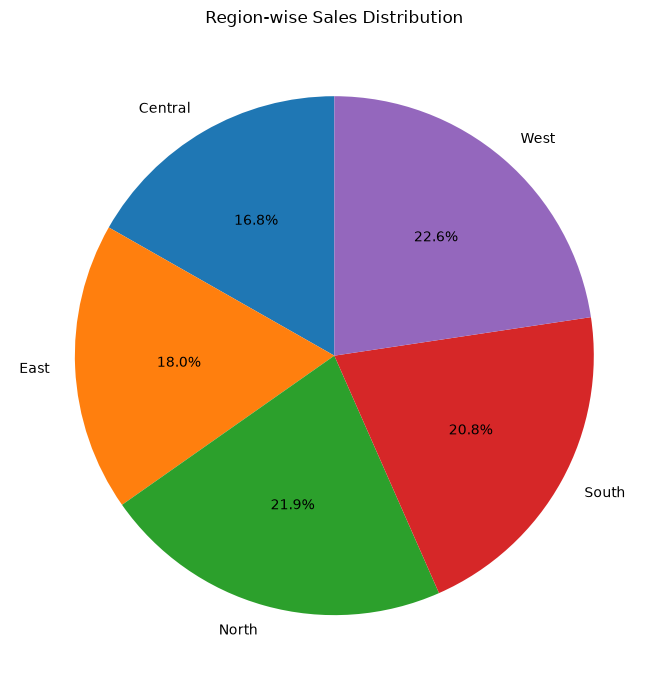


========== Data Analysis & Visualization Program ==========
Please select an option:
1. Load Dataset
2. Explore Data
3. Perform DataFrame Operations
4. Handle Missing Data
5. Generate Descriptive Statistics
6. Data Visualization
7. Save Visualization
8. Exit



Enter your choice:  7



== Save Visualization ==


Enter file name (without extension):  pie_chart



Choose File Format:
1. PNG
2. JPEG


Enter your choice:  1



Visualization saved as pie_chart.png

========== Data Analysis & Visualization Program ==========
Please select an option:
1. Load Dataset
2. Explore Data
3. Perform DataFrame Operations
4. Handle Missing Data
5. Generate Descriptive Statistics
6. Data Visualization
7. Save Visualization
8. Exit



Enter your choice:  8



Exiting the program. Goodbye!


In [3]:
analyzer = SalesDataAnalyzer()
analyzer.main_menu()
# analyzer.load_data()
# analyzer.explore_data()